In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import lazypredict
from lazypredict.Supervised import LazyClassifier
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [54]:
df = pd.read_pickle("FingerprintsAll.csv")
df = df.sample(frac=1).reset_index(drop=True)
df

,Name,fp_MACCS,fp_Morgan_512B,fp_Morgan_512B_r3,fp_Morgan_1024B,fp_Morgan_1024B_r3,fp_MAP4_512B,fp_MAP4_512B_r3,fp_MAP4_1024B,fp_MAP4_1024B_r3,Toxicity
0,D09572,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, ...","[1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, ...","[1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, ...","[1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, ...",0
1,ZINC02038819,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",1
2,ZINC71624960,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, ...",1
3,T3DB0377,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1
4,D04098,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, ...","[1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0
...,...,...,...,...,...,...,...,...,...,...,...
6398,D01970,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, ...","[1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, ...","[1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, ...",0
6399,D05967,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, ...","[0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, ...",0
6400,ZINC01532072,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, ...","[1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, ...","[1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0

#### By using fingerprints 

In [55]:
#### MACCS FP
X1 = np.array(list((df['fp_MACCS']))).astype(float)
#X.shape
Y1 = df["Toxicity"].values
# Split the data into training and test set
# Perform data splitting using 80/20 ratio
X_train1, X_test1, Y_train1, Y_test1 = train_test_split(X1, Y1, test_size=0.2, random_state=782)
# Print the shape of training and testing data
print("Shape of training data:", X_train1.shape)
print("Shape of test data:", X_test1.shape)
# Defines and builds the LazyClassifier
clf1 =  LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
model1,predictions1 = clf1.fit(X_train1, X_test1, Y_train1, Y_test1)
predictions1.sort_values(by="F1 Score", ascending=False, inplace=True)
predictions1

Shape of training data: (5122, 167)
Shape of test data: (1281, 167)


  0%|          | 0/31 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2262, number of negative: 2860
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006922 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 447
[LightGBM] [Info] Number of data points in the train set: 5122, number of used features: 149
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.441624 -> initscore=-0.234572
[LightGBM] [Info] Start training from score -0.234572


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
NuSVC,0.79,0.79,0.79,0.79,1.61
SVC,0.79,0.79,0.79,0.79,1.36
LGBMClassifier,0.79,0.78,0.78,0.79,0.16
XGBClassifier,0.78,0.78,0.78,0.78,35.96
ExtraTreesClassifier,0.77,0.77,0.77,0.77,0.57
RandomForestClassifier,0.77,0.76,0.76,0.77,0.46
RidgeClassifierCV,0.77,0.76,0.76,0.76,0.73
LinearDiscriminantAnalysis,0.76,0.76,0.76,0.76,0.18
RidgeClassifier,0.76,0.76,0.76,0.76,0.03


### Morgan FP

In [56]:
#### Morgan 512 Bits with r=2
X2 = np.array(list((df['fp_Morgan_512B']))).astype(float)
#X.shape
Y2 = df["Toxicity"].values
# Split the data into training and test set
# Perform data splitting using 80/20 ratio
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(X2, Y2, test_size=0.2, random_state=782)
# Print the shape of training and testing data
print("Shape of training data:", X_train2.shape)
print("Shape of test data:", X_test2.shape)
# Defines and builds the LazyClassifier
clf2 =  LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
model2,predictions2 = clf2.fit(X_train2, X_test2, Y_train2, Y_test2)
predictions2.sort_values(by="F1 Score", ascending=False, inplace=True)

# NBVAL_CHECK_OUTPUT

Shape of training data: (5122, 512)
Shape of test data: (1281, 512)


  0%|          | 0/31 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2262, number of negative: 2860
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004110 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1536
[LightGBM] [Info] Number of data points in the train set: 5122, number of used features: 512
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.441624 -> initscore=-0.234572
[LightGBM] [Info] Start training from score -0.234572


In [57]:
#### Morgan 512 Bits with r=3 
X3 = np.array(list((df['fp_Morgan_512B_r3']))).astype(float)
#X.shape
Y3 = df["Toxicity"].values
# Split the data into training and test set
# Perform data splitting using 80/20 ratio
X_train3, X_test3, Y_train3, Y_test3 = train_test_split(X3, Y3, test_size=0.2, random_state=32)
# Print the shape of training and testing data
print("Shape of training data:", X_train3.shape)
print("Shape of test data:", X_test3.shape)
# Defines and builds the LazyClassifier
clf3 =  LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
model3,predictions3 = clf3.fit(X_train3, X_test3, Y_train3, Y_test3)
predictions3.sort_values(by="F1 Score", ascending=False, inplace=True)

# NBVAL_CHECK_OUTPUT

Shape of training data: (5122, 512)
Shape of test data: (1281, 512)


  0%|          | 0/31 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2245, number of negative: 2877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026564 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1536
[LightGBM] [Info] Number of data points in the train set: 5122, number of used features: 512
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.438305 -> initscore=-0.248043
[LightGBM] [Info] Start training from score -0.248043


In [58]:
#### Morgan 1024 Bits with r=2 
X4 = np.array(list((df['fp_Morgan_1024B']))).astype(float)
#X.shape
Y4 = df["Toxicity"].values
# Split the data into training and test set
# Perform data splitting using 80/20 ratio
X_train4, X_test4, Y_train4, Y_test4 = train_test_split(X4, Y4, test_size=0.2, random_state=782)
# Print the shape of training and testing data
print("Shape of training data:", X_train4.shape)
print("Shape of test data:", X_test4.shape)
# Defines and builds the LazyClassifier
clf4 =  LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
model4,predictions4 = clf4.fit(X_train4, X_test4, Y_train4, Y_test4)
predictions4.sort_values(by="F1 Score", ascending=False, inplace=True)
# NBVAL_CHECK_OUTPUT

Shape of training data: (5122, 1024)
Shape of test data: (1281, 1024)


  0%|          | 0/31 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2262, number of negative: 2860
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.108022 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3069
[LightGBM] [Info] Number of data points in the train set: 5122, number of used features: 1023
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.441624 -> initscore=-0.234572
[LightGBM] [Info] Start training from score -0.234572


In [59]:
#### Morgan 1024 Bits with r=3 
X5 = np.array(list((df['fp_Morgan_1024B_r3']))).astype(float)
#X.shape
Y5 = df["Toxicity"].values
# Split the data into training and test set
# Perform data splitting using 80/20 ratio
X_train5, X_test5, Y_train5, Y_test5 = train_test_split(X5, Y5, test_size=0.2, random_state=782)
# Print the shape of training and testing data
print("Shape of training data:", X_train5.shape)
print("Shape of test data:", X_test5.shape)
# Defines and builds the LazyClassifier
clf5 =  LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
model5,predictions5 = clf5.fit(X_train5, X_test5, Y_train5, Y_test5)
predictions5.sort_values(by="F1 Score", ascending=False, inplace=True)
predictions5

Shape of training data: (5122, 1024)
Shape of test data: (1281, 1024)


  0%|          | 0/31 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2262, number of negative: 2860
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.212232 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3072
[LightGBM] [Info] Number of data points in the train set: 5122, number of used features: 1024
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.441624 -> initscore=-0.234572
[LightGBM] [Info] Start training from score -0.234572


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
SVC,0.77,0.77,0.77,0.77,8.25
NuSVC,0.76,0.76,0.76,0.76,10.55
LGBMClassifier,0.76,0.75,0.75,0.76,6.39
XGBClassifier,0.75,0.75,0.75,0.75,42.35
ExtraTreesClassifier,0.75,0.74,0.74,0.75,2.13
RandomForestClassifier,0.75,0.74,0.74,0.75,1.69
BernoulliNB,0.73,0.73,0.73,0.73,0.11
AdaBoostClassifier,0.73,0.73,0.73,0.73,1.79
NearestCentroid,0.73,0.73,0.73,0.73,0.13


### MAP4 fingerprints

In [60]:
#### MAP4 FP 512 Bits and r=2 
X6 = np.array(list((df['fp_MAP4_512B']))).astype(float)
#X.shape
Y6 = df["Toxicity"].values
# Split the data into training and test set
# Perform data splitting using 30/20 ratio
X_train6, X_test6, Y_train6, Y_test6 = train_test_split(X6, Y6, test_size=0.2, random_state=782)
# Print the shape of training and testing data
print("Shape of training data:", X_train6.shape)
print("Shape of test data:", X_test6.shape)
# Defines and builds the LazyClassifier
clf6 =  LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
model6,predictions6 = clf6.fit(X_train6, X_test6, Y_train6, Y_test6)
predictions6.sort_values(by="F1 Score", ascending=False, inplace=True)


Shape of training data: (5122, 512)
Shape of test data: (1281, 512)


  0%|          | 0/31 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2262, number of negative: 2860
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034412 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1536
[LightGBM] [Info] Number of data points in the train set: 5122, number of used features: 512
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.441624 -> initscore=-0.234572
[LightGBM] [Info] Start training from score -0.234572


In [61]:
#### MAP4 FP 512 Bits and r=3  
X7 = np.array(list((df['fp_MAP4_512B_r3']))).astype(float)
#X.shape
Y7 = df["Toxicity"].values
# Split the data into training and test set
# Perform data splitting using 80/20 ratio
X_train7, X_test7, Y_train7, Y_test7 = train_test_split(X7, Y7, test_size=0.2, random_state=72)
# Print the shape of training and testing data
print("Shape of training data:", X_train7.shape)
print("Shape of test data:", X_test7.shape)
# Defines and builds the LazyClassifier
clf7 =  LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
model7,predictions7 = clf7.fit(X_train7, X_test7, Y_train7, Y_test7)
predictions7.sort_values(by="F1 Score", ascending=False, inplace=True)
predictions7

Shape of training data: (5122, 512)
Shape of test data: (1281, 512)


  0%|          | 0/31 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2277, number of negative: 2845
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003756 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1536
[LightGBM] [Info] Number of data points in the train set: 5122, number of used features: 512
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.444553 -> initscore=-0.222704
[LightGBM] [Info] Start training from score -0.222704


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
SVC,0.74,0.73,0.73,0.74,3.06
LGBMClassifier,0.73,0.72,0.72,0.73,0.30
AdaBoostClassifier,0.73,0.72,0.72,0.73,1.10
NuSVC,0.73,0.72,0.72,0.73,3.24
NearestCentroid,0.73,0.72,0.72,0.73,0.07
BernoulliNB,0.72,0.72,0.72,0.72,0.07
GaussianNB,0.72,0.72,0.72,0.72,0.06
ExtraTreesClassifier,0.73,0.72,0.72,0.72,1.22
RandomForestClassifier,0.72,0.71,0.71,0.72,0.87


In [62]:
#### MAP4 FP 1024 Bits and r=2 
X8 = np.array(list((df['fp_MAP4_1024B']))).astype(float)
#X.shape
Y8 = df["Toxicity"].values
# Split the data into training and test set
# Perform data splitting using 80/20 ratio
X_train8, X_test8, Y_train8, Y_test8 = train_test_split(X8, Y8, test_size=0.2, random_state=782)
# Print the shape of training and testing data
print("Shape of training data:", X_train8.shape)
print("Shape of test data:", X_test8.shape)
# Defines and builds the LazyClassifier
clf8 =  LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
model8,predictions8 = clf8.fit(X_train8, X_test8, Y_train8, Y_test8)
predictions8.sort_values(by="F1 Score", ascending=False, inplace=True)
predictions8

Shape of training data: (5122, 1024)
Shape of test data: (1281, 1024)


  0%|          | 0/31 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2262, number of negative: 2860
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009861 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3072
[LightGBM] [Info] Number of data points in the train set: 5122, number of used features: 1024
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.441624 -> initscore=-0.234572
[LightGBM] [Info] Start training from score -0.234572


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
SVC,0.76,0.75,0.75,0.75,8.10
LGBMClassifier,0.75,0.74,0.74,0.74,0.50
NuSVC,0.75,0.74,0.74,0.74,9.30
XGBClassifier,0.73,0.72,0.72,0.72,32.10
ExtraTreesClassifier,0.73,0.72,0.72,0.72,1.96
RandomForestClassifier,0.72,0.72,0.72,0.72,1.42
AdaBoostClassifier,0.72,0.71,0.71,0.71,2.51
Perceptron,0.71,0.71,0.71,0.71,0.17
PassiveAggressiveClassifier,0.71,0.71,0.71,0.71,0.22


In [63]:
#### MAP4 FP 1024 Bits and r=3 
X9 = np.array(list((df['fp_MAP4_1024B_r3']))).astype(float)
#X.shape
Y9 = df["Toxicity"].values
# Split the data into training and test set
# Perform data splitting using 80/20 ratio
X_train9, X_test9, Y_train9, Y_test9 = train_test_split(X9, Y9, test_size=0.2, random_state=782)
# Print the shape of training and testing data
print("Shape of training data:", X_train9.shape)
print("Shape of test data:", X_test9.shape)
# Defines and builds the LazyClassifier
clf9 =  LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
model9,predictions9 = clf9.fit(X_train9, X_test9, Y_train9, Y_test9)
predictions9.sort_values(by="F1 Score", ascending=False, inplace=True)
predictions9

Shape of training data: (5122, 1024)
Shape of test data: (1281, 1024)


  0%|          | 0/31 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2262, number of negative: 2860
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003688 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3072
[LightGBM] [Info] Number of data points in the train set: 5122, number of used features: 1024
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.441624 -> initscore=-0.234572
[LightGBM] [Info] Start training from score -0.234572


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
SVC,0.74,0.73,0.73,0.73,8.20
NuSVC,0.73,0.73,0.73,0.73,9.28
ExtraTreesClassifier,0.72,0.71,0.71,0.72,1.95
LGBMClassifier,0.72,0.71,0.71,0.71,0.57
RandomForestClassifier,0.72,0.71,0.71,0.71,1.39
XGBClassifier,0.71,0.71,0.71,0.71,31.85
AdaBoostClassifier,0.70,0.70,0.70,0.70,2.69
BernoulliNB,0.69,0.70,0.70,0.69,0.15
GaussianNB,0.69,0.69,0.69,0.69,0.11


### 1D descriptors

In [64]:
df2 = pd.read_pickle("1DDescriptors.csv")
df2

,Name,1Ddescriptors,Toxicity
0,DB00014,"[1268.6414393679997, 1269.4330000000002, 32.0,...",0
1,DB00035,"[1068.426955488, 1069.2379999999998, 26.0, 18....",0
2,DB00050,"[1429.6698183039998, 1431.0640000000003, 31.0,...",0
3,DB00091,"[1201.8413679919997, 1202.634999999999, 23.0, ...",0
4,DB00093,"[1039.4367919000001, 1040.2399999999996, 24.0,...",0
...,...,...,...
8942,ZINC98359253,"[104.094963004, 104.15299999999999, 3.0, 4.0, ...",1
8943,ZINC98359257,"[264.05514552600005, 264.21700000000004, 4.0, ...",1
8944,ZINC98359263,"[176.1412445, 176.25599999999997, 3.0, 1.0, 7....",1
8945,ZINC98359322,"[171.125928784, 171.23999999999998, 3.0, 1.0, ...",1


In [65]:

from sklearn.preprocessing import StandardScaler

X10 = np.array(list((df2['1Ddescriptors']))).astype(float)
#X.shape
Y10 = df2["Toxicity"].values
# Split the data into training and test set
# Perform data splitting using 80/20 ratio
X_train10, X_test10, Y_train10, Y_test10 = train_test_split(X10, Y10, test_size=0.2, random_state=782)
scaler = StandardScaler()
X_train10_scaled=scaler.fit_transform(X_train10)
X_test10_scaled=scaler.transform(X_test10)
# Print the shape of training and testing data
print("Shape of training data:", X_train10_scaled.shape)
print("Shape of test data:", X_test10_scaled.shape)
# Defines and builds the LazyClassifier
clf10 =  LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
model10,predictions10 = clf10.fit(X_train10_scaled, X_test10_scaled, Y_train10, Y_test10)
predictions10.sort_values(by="F1 Score", ascending=False, inplace=True)
predictions10

Shape of training data: (5122, 43)
Shape of test data: (1281, 43)


  0%|          | 0/31 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2288, number of negative: 2834
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000433 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6071
[LightGBM] [Info] Number of data points in the train set: 5122, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.446701 -> initscore=-0.214011
[LightGBM] [Info] Start training from score -0.214011


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
NuSVC,0.78,0.77,0.77,0.77,1.04
SVC,0.78,0.77,0.77,0.77,0.81
LGBMClassifier,0.77,0.77,0.77,0.77,0.17
XGBClassifier,0.77,0.77,0.77,0.77,31.10
ExtraTreesClassifier,0.76,0.76,0.76,0.76,0.39
RandomForestClassifier,0.76,0.75,0.75,0.76,1.21
KNeighborsClassifier,0.75,0.75,0.75,0.75,0.01
CalibratedClassifierCV,0.75,0.75,0.75,0.75,0.40
LinearSVC,0.75,0.75,0.75,0.75,0.07


### Save all th results to an Excel File

In [66]:
with pd.ExcelWriter("LazyPredictResults.xlsx") as writer:
   
    # use to_excel function and specify the sheet_name and index 
    # to store the dataframe in specified sheet
    predictions10.to_excel(writer, sheet_name="1D descriptors", )
    predictions1.to_excel(writer, sheet_name="MACCS", )
    predictions2.to_excel(writer, sheet_name="Morgan 512 Bits", )
    predictions3.to_excel(writer, sheet_name="Morgan 512 Bits with r=3", )
    predictions4.to_excel(writer, sheet_name="Morgan 1024 Bits", )
    predictions5.to_excel(writer, sheet_name="Morgan 1024 Bits with r=3", )
    predictions6.to_excel(writer, sheet_name="MAP4 512 Bits", )
    predictions7.to_excel(writer, sheet_name="MAP4 512 Bits with 3", )
    predictions8.to_excel(writer, sheet_name="MAP4 1024 Bits", )
    predictions9.to_excel(writer, sheet_name="MAP4 1024 Bits with r=3", )
    
    
    

In [67]:
fp_results = {
    "1D descriptors": predictions10,
    "MACCS": predictions1,
    "Morgan 512 Bits": predictions2, 
    "Morgan 512 Bits with r=3": predictions3, 
    "Morgan 1024 Bits": predictions4,
    "Morgan 1024 Bits with r=3": predictions5, 
    "MAP4 512 Bits": predictions6,
    "MAP4 512 Bits with 3": predictions7, 
    "MAP4 1024 Bits": predictions8,
    "MAP4 1024 Bits with r=3": predictions9, 
}

In [68]:
dfs = []

for fp_name, df in fp_results.items():
    tmp = df[["F1 Score", "Balanced Accuracy"]].copy()
    
    # create multi-level columns: (FP_name, metric)
    tmp.columns = pd.MultiIndex.from_product(
        [ [fp_name], tmp.columns ]
    )
    
    dfs.append(tmp)

final_table = pd.concat(dfs, axis=1)

In [69]:
mean_f1 = final_table.xs("F1 Score", level=1, axis=1).mean(axis=1)
final_table = final_table.loc[mean_f1.sort_values(ascending=False).index]

In [70]:
final_table

1D descriptors                      MACCS  \
                                    F1 Score Balanced Accuracy F1 Score   
Model                                                                     
SVC                                     0.77              0.77     0.79   
NuSVC                                   0.77              0.77     0.79   
LGBMClassifier                          0.77              0.77     0.79   
XGBClassifier                           0.77              0.77     0.78   
RandomForestClassifier                  0.76              0.75     0.77   
ExtraTreesClassifier                    0.76              0.76     0.77   
AdaBoostClassifier                      0.74              0.73     0.74   
RidgeClassifierCV                       0.75              0.74     0.76   
LinearDiscriminantAnalysis              0.75              0.74     0.76   
RidgeClassifier                         0.74              0.74     0.76   
LinearSVC                               0.75              0.75     0.76   
CalibratedClassifierCV                  0.75              0.75     0.76   
LogisticRegression                      0.74              0.74     0.76   
BernoulliNB                             0.68              0.69     0.72   
NearestCentroid                         0.68              0.69     0.72   
GaussianNB                              0.70              0.70     0.69   
BaggingClassifier                       0.73              0.73     0.73   
Perceptron                              0.73              0.73     0.69   
SGDClassifier                           0.75              0.75     0.70   
QuadraticDiscriminantAnalysis           0.69              0.69     0.62   
DecisionTreeClassifier                  0.69              0.69     0.69   
ExtraTreeClassifier                     0.67              0.67     0.70   
PassiveAggressiveClassifier             0.42              0.42     0.65   
KNeighborsClassifier                    0.75              0.75     0.76   
LabelSpreading                          0.72              0.72     0.65   
LabelPropagation                        0.72              0.72     0.65   
DummyClassifier                         0.39              0.50     0.37   

                                                Morgan 512 Bits  \
                              Balanced Accuracy        F1 Score   
Model                                                             
SVC                                        0.79            0.76   
NuSVC                                      0.79            0.76   
LGBMClassifier                             0.78            0.76   
XGBClassifier                              0.78            0.76   
RandomForestClassifier                     0.76            0.76   
ExtraTreesClassifier                       0.77            0.75   
AdaBoostClassifier                         0.74            0.73   
RidgeClassifierCV                          0.76            0.74   
LinearDiscriminantAnalysis                 0.76            0.74   
RidgeClassifier                            0.76            0.74   
LinearSVC                                  0.76            0.73   
CalibratedClassifierCV                     0.76            0.73   
LogisticRegression                         0.76            0.74   
BernoulliNB                                0.72            0.73   
NearestCentroid                            0.72            0.73   
GaussianNB                                 0.70            0.72   
BaggingClassifier                          0.73            0.71   
Perceptron                                 0.69            0.67   
SGDClassifier                              0.69            0.67   
QuadraticDiscriminantAnalysis              0.62            0.74   
DecisionTreeClassifier                     0.69            0.67   
ExtraTreeClassifier                        0.70            0.66   
PassiveAggressiveClassifier                0.64            0.67   
KNeighborsClassifier                 

In [71]:
#final_table.to_csv("FP_comparison_table.csv")
final_table.to_excel("FP_comparison_table.xlsx")

In [79]:
final_table.xs("Balanced Accuracy", level=1, axis=1).max().sort_values(ascending=False)

MACCS                       0.79
1D descriptors              0.77
Morgan 1024 Bits with r=3   0.77
Morgan 512 Bits with r=3    0.76
Morgan 512 Bits             0.76
Morgan 1024 Bits            0.76
MAP4 1024 Bits              0.75
MAP4 512 Bits               0.73
MAP4 512 Bits with 3        0.73
MAP4 1024 Bits with r=3     0.73
dtype: float64

In [80]:
final_table.xs("F1 Score", level=1, axis=1).max().sort_values(ascending=False)

MACCS                       0.79
1D descriptors              0.77
Morgan 1024 Bits with r=3   0.77
Morgan 512 Bits             0.76
Morgan 512 Bits with r=3    0.76
Morgan 1024 Bits            0.76
MAP4 1024 Bits              0.75
MAP4 512 Bits               0.74
MAP4 512 Bits with 3        0.74
MAP4 1024 Bits with r=3     0.73
dtype: float64

In [74]:
fp = "MACCS"

top5 = (
    final_table[fp]["Balanced Accuracy"]
    .sort_values(ascending=False)
    .head(5)
)
top5

Model
NuSVC                  0.79
SVC                    0.79
LGBMClassifier         0.78
XGBClassifier          0.78
ExtraTreesClassifier   0.77
Name: Balanced Accuracy, dtype: float64

In [81]:
fp = "MACCS"

top5 = (
    final_table[fp]["F1 Score"]
    .sort_values(ascending=False)
    .head(5)
)
top5

Model
NuSVC                  0.79
SVC                    0.79
LGBMClassifier         0.79
XGBClassifier          0.78
ExtraTreesClassifier   0.77
Name: F1 Score, dtype: float64

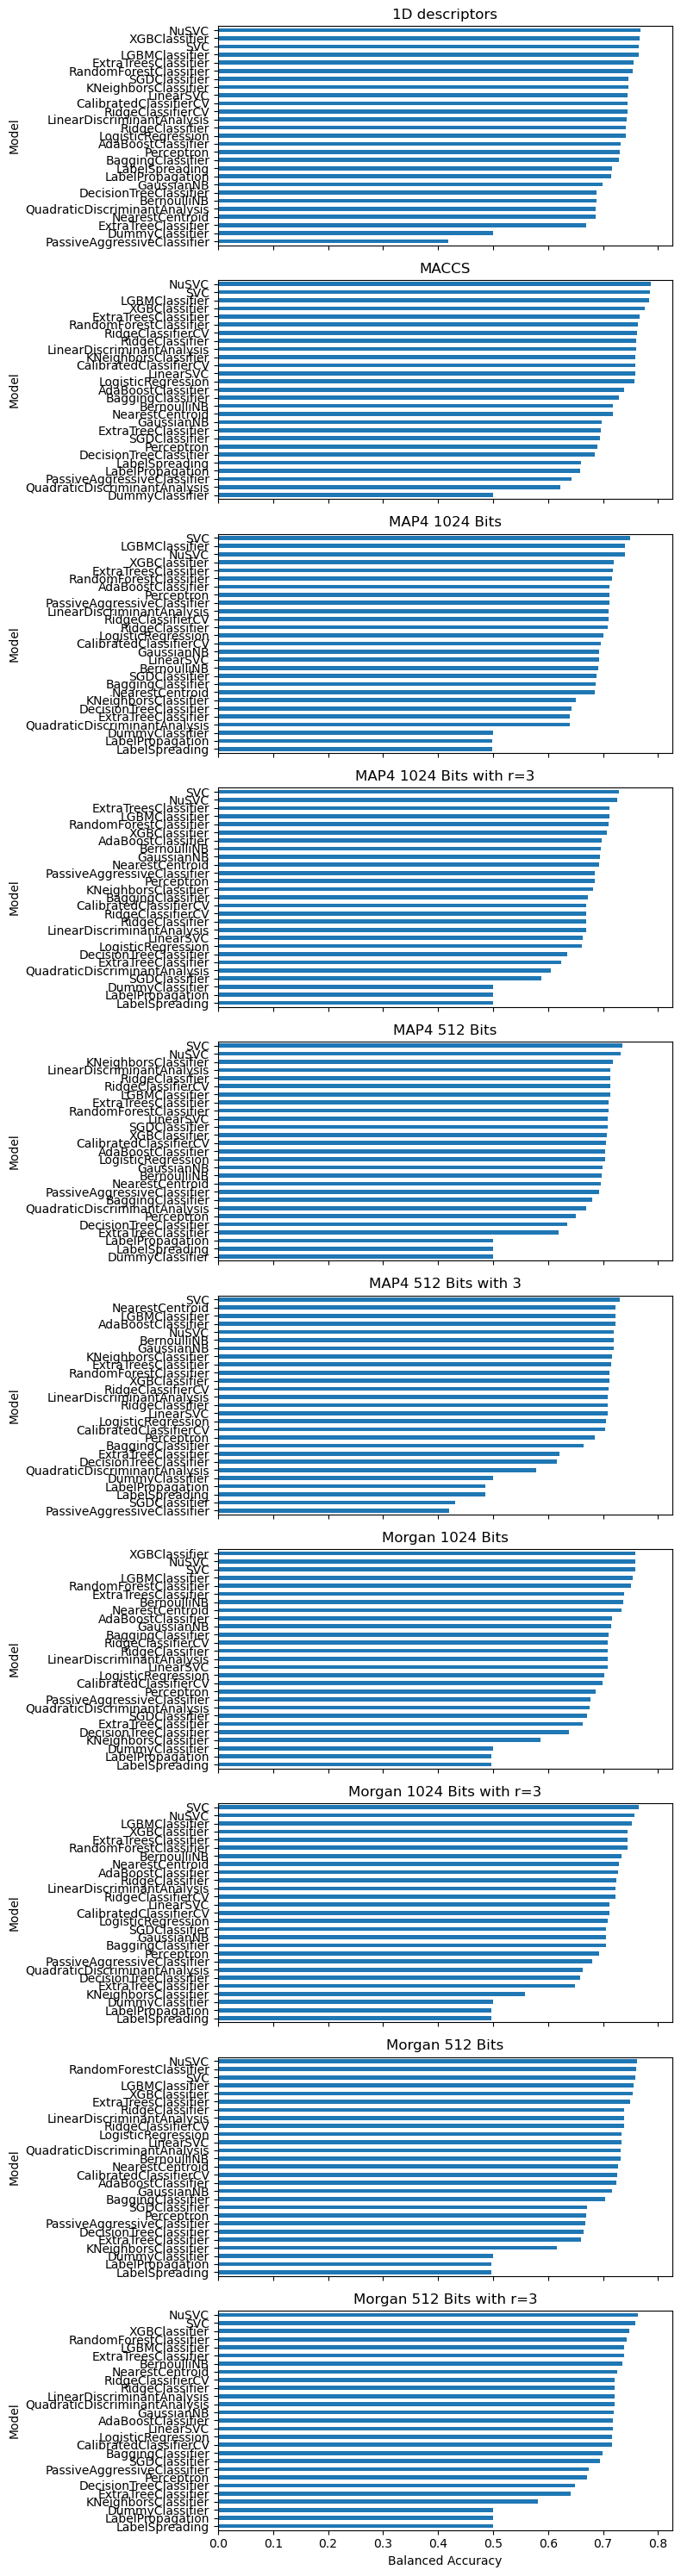

In [75]:
fps = final_table.columns.levels[0]

fig, axes = plt.subplots(len(fps), 1, figsize=(8, 3*len(fps)), sharex=True)

for ax, fp in zip(axes, fps):
    final_table[fp]["Balanced Accuracy"].sort_values().plot(
        kind="barh", ax=ax
    )
    ax.set_title(fp)
    ax.set_xlabel("Balanced Accuracy")

plt.tight_layout()
plt.show()

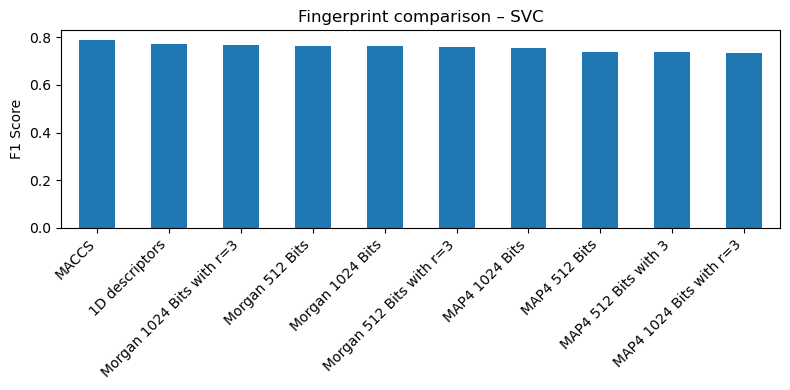

In [76]:
model_name = "SVC"

data = final_table.loc[model_name].xs(
    "F1 Score", level=1
).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
data.plot(kind="bar")
plt.ylabel("F1 Score")
plt.title(f"Fingerprint comparison – {model_name}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [77]:
df2[df2["Toxicity"] == 0]


,Name,1Ddescriptors,Toxicity
0,DB00014,"[1268.6414393679997, 1269.4330000000002, 32.0,...",0
1,DB00035,"[1068.426955488, 1069.2379999999998, 26.0, 18....",0
2,DB00050,"[1429.6698183039998, 1431.0640000000003, 31.0,...",0
3,DB00091,"[1201.8413679919997, 1202.634999999999, 23.0, ...",0
4,DB00093,"[1039.4367919000001, 1040.2399999999996, 24.0,...",0
...,...,...,...
4888,D10883,"[434.25425758000006, 434.54800000000023, 9.0, ...",0
4889,D10886,"[562.3379872040001, 562.7190000000003, 11.0, 3...",0
4890,D10887,"[462.23793882000007, 462.5540000000002, 9.0, 1...",0
4891,D10892,"[466.117412812, 466.48100000000017, 6.0, 2.0, ...",0


In [78]:
df2[df2["Toxicity"] == 1]


,Name,1Ddescriptors,Toxicity
4893,T3DB0016,"[129.914383072, 131.389, 0.0, 0.0, 0.0, 0.0, 0...",1
4895,T3DB0021,"[315.938010976, 318.0300000000001, 0.0, 0.0, 2...",1
4896,T3DB0022,"[257.81311608, 260.762, 0.0, 0.0, 1.0, 0.0, 0....",1
4897,T3DB0026,"[184.100048384, 184.242, 2.0, 4.0, 1.0, 2.0, 2...",1
4898,T3DB0031,"[407.813421696, 411.7980000000001, 0.0, 0.0, 2...",1
...,...,...,...
8942,ZINC98359253,"[104.094963004, 104.15299999999999, 3.0, 4.0, ...",1
8943,ZINC98359257,"[264.05514552600005, 264.21700000000004, 4.0, ...",1
8944,ZINC98359263,"[176.1412445, 176.25599999999997, 3.0, 1.0, 7....",1
8945,ZINC98359322,"[171.125928784, 171.23999999999998, 3.0, 1.0, ...",1
